In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [90]:
url = "https://raw.githubusercontent.com/Asif117204/asif/master/ANN/diabetes.csv"

df = pd.read_csv(url)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [91]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [92]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

In [93]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [94]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [95]:
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

In [96]:
X_train_tensor = torch.FloatTensor(X_train2)
y_train_tensor = torch.FloatTensor(y_train2.values).reshape(-1,1)

X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val.values).reshape(-1,1)

X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test.values).reshape(-1,1)

In [97]:
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [98]:
class ShallowNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(8,32)
        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(32,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self,x):

        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))

        return x

In [99]:
class DeepNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(8,64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64,32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32,16),
            nn.ReLU(),

            nn.Linear(16,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.network(x)

In [100]:
def train_model(model, optimizer, epochs):

    criterion = nn.BCELoss()

    train_loss=[]
    val_loss=[]

    train_acc=[]
    val_acc=[]

    for epoch in range(epochs):

        model.train()

        total_loss=0
        correct=0

        for xb,yb in train_loader:

            optimizer.zero_grad()

            outputs=model(xb)

            loss=criterion(outputs,yb)

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

            pred=(outputs>0.5).float()

            correct += (pred==yb).sum().item()

        train_loss.append(total_loss/len(train_loader))
        train_acc.append(correct/len(y_train_tensor))

        #### validation

        model.eval()

        with torch.no_grad():

            val_output=model(X_val_tensor)

            vloss=criterion(val_output,y_val_tensor)

            val_loss.append(vloss.item())

            pred=(val_output>0.5).float()

            vacc=(pred==y_val_tensor).sum().item()/len(y_val_tensor)

            val_acc.append(vacc)

    return train_loss,val_loss,train_acc,val_acc

In [101]:
shallow_model = ShallowNN()

optimizer1 = torch.optim.Adam(
    shallow_model.parameters(),
    lr=0.001
)

s_train_loss,s_val_loss,s_train_acc,s_val_acc = train_model(
    shallow_model,
    optimizer1,
    epochs=100
)

In [102]:
deep_model = DeepNN()

optimizer2 = torch.optim.Adam(
    deep_model.parameters(),
    lr=0.001,
    weight_decay=0.001
)

d_train_loss,d_val_loss,d_train_acc,d_val_acc = train_model(
    deep_model,
    optimizer2,
    epochs=100
)

In [103]:
def evaluate(model):

    model.eval()

    with torch.no_grad():

        probs=model(X_test_tensor)

        probs=probs.numpy()

        pred=(probs>0.5).astype(int)

    return pred,probs

In [104]:
s_pred,s_prob=evaluate(shallow_model)
d_pred,d_prob=evaluate(deep_model)

In [105]:
metrics = {}

for name,pred,prob in [
    ('Shallow',s_pred,s_prob),
    ('Deep',d_pred,d_prob)
]:

    metrics[name]=[
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred),
        roc_auc_score(y_test,prob)
    ]

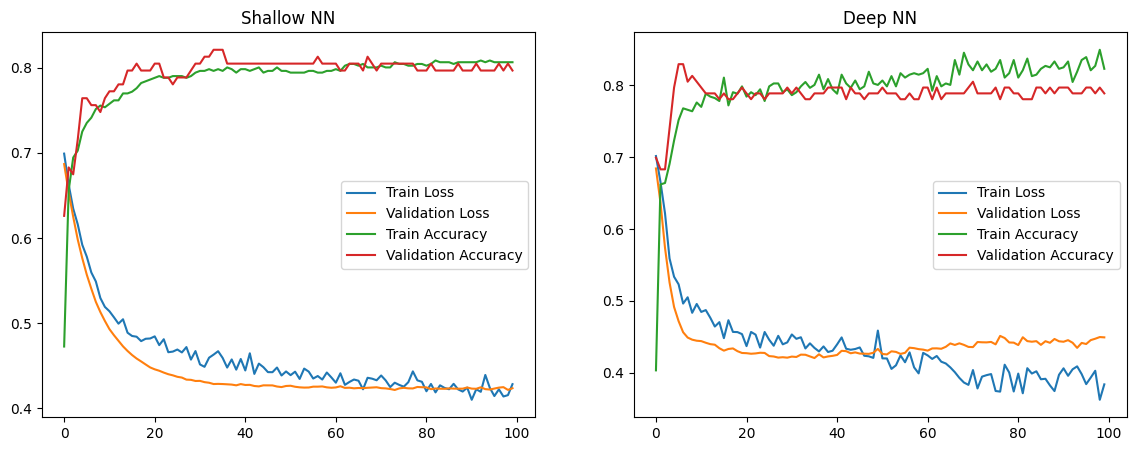

In [106]:
fig,ax=plt.subplots(1,2,figsize=(14,5))

ax[0].plot(s_train_loss,label='Train Loss')
ax[0].plot(s_val_loss,label='Validation Loss')
ax[0].plot(s_train_acc,label='Train Accuracy')
ax[0].plot(s_val_acc,label='Validation Accuracy')
ax[0].set_title("Shallow NN")
ax[0].legend()

ax[1].plot(d_train_loss,label='Train Loss')
ax[1].plot(d_val_loss,label='Validation Loss')
ax[1].plot(d_train_acc,label='Train Accuracy')
ax[1].plot(d_val_acc,label='Validation Accuracy')
ax[1].set_title("Deep NN")
ax[1].legend()

plt.show()

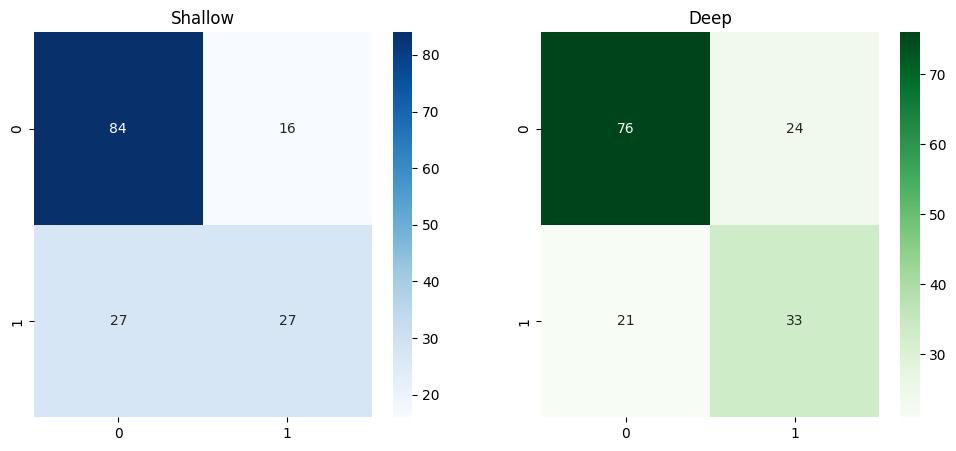

In [107]:
fig,ax=plt.subplots(1,2,figsize=(12,5))

sns.heatmap(
    confusion_matrix(y_test,s_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax[0]
)

ax[0].set_title("Shallow")

sns.heatmap(
    confusion_matrix(y_test,d_pred),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=ax[1]
)

ax[1].set_title("Deep")

plt.show()

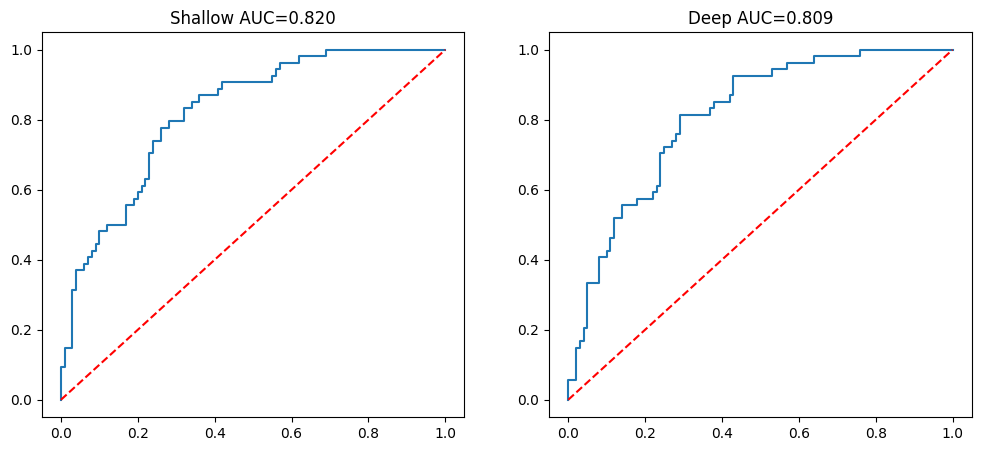

In [108]:
fig,ax=plt.subplots(1,2,figsize=(12,5))

fpr,tpr,_=roc_curve(y_test,s_prob)

auc1=roc_auc_score(y_test,s_prob)

ax[0].plot(fpr,tpr)
ax[0].plot([0,1],[0,1],'r--')
ax[0].set_title(f"Shallow AUC={auc1:.3f}")

fpr,tpr,_=roc_curve(y_test,d_prob)

auc2=roc_auc_score(y_test,d_prob)

ax[1].plot(fpr,tpr)
ax[1].plot([0,1],[0,1],'r--')
ax[1].set_title(f"Deep AUC={auc2:.3f}")

plt.show()

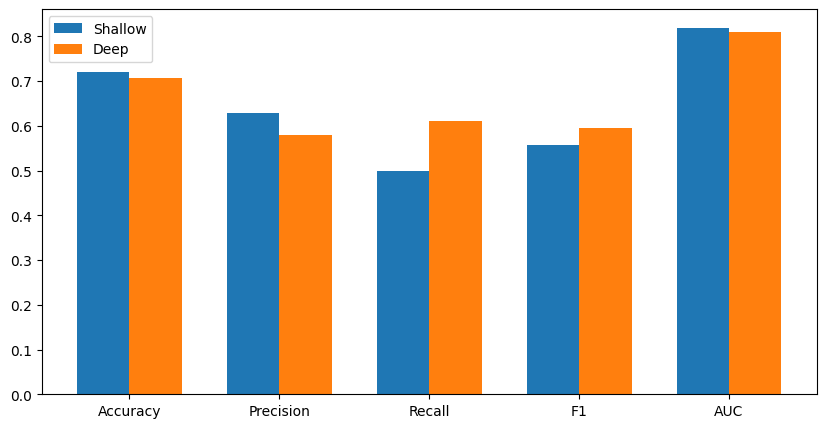

In [109]:
labels=['Accuracy','Precision','Recall','F1','AUC']

x=np.arange(len(labels))
width=0.35

plt.figure(figsize=(10,5))

plt.bar(
    x-width/2,
    metrics['Shallow'],
    width,
    label='Shallow'
)

plt.bar(
    x+width/2,
    metrics['Deep'],
    width,
    label='Deep'
)

plt.xticks(x,labels)
plt.legend()

plt.show()

In [110]:
!pip install graphviz pydot
!apt-get install graphviz -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [111]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import plot_model

shallow_model_plot = Sequential([
    Dense(32, activation='relu', input_shape=(8,), name='Hidden_Layer'),
    Dense(1, activation='sigmoid', name='Output_Layer')
])

shallow_model_plot.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer (Dense)            │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

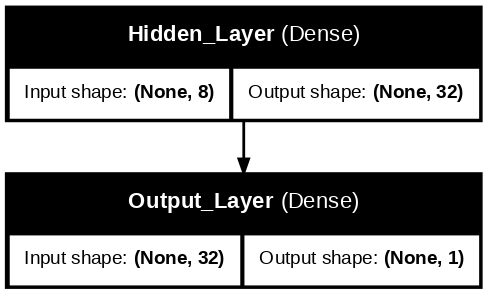

In [112]:
plot_model(
    shallow_model_plot,
    to_file='shallow_nn.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',
    dpi=100
)

In [113]:
from tensorflow.keras.layers import Dropout

deep_model_plot = Sequential([
    Dense(64, activation='relu', input_shape=(8,), name='Hidden1'),
    Dropout(0.3),

    Dense(32, activation='relu', name='Hidden2'),
    Dropout(0.3),

    Dense(16, activation='relu', name='Hidden3'),

    Dense(1, activation='sigmoid', name='Output')
])

deep_model_plot.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden1 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
plot_model(
    deep_model_plot,
    to_file='deep_nn.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',
    dpi=100
)

## Performance Interpretation & Analysis

The Deep Neural Network achieved slightly higher Accuracy, F1-score, and AUC compared to the Shallow Neural Network.

Although both models converged successfully, the Deep model showed a slightly larger gap between training and validation performance, indicating mild overfitting.

Overall, the use of Dropout and L2 regularization improved generalization, and the deeper architecture provided a justifiable performance gain over the shallow network.